# CAZ Interactive Demo

*Run an LLM on your own concept pairs and watch CAZ emerge*

This notebook loads a language model and computes a full CAZ analysis on any concept you choose. Provide 10–20 contrastive sentence pairs and the notebook will show:
- Where in the model the concept crystallises (separation peak)
- Whether allocation is multimodal (two distinct assembly events)
- How your concept's peak depth compares to the 17 concepts from the paper

**Hardware requirements by model tier:**

| Tier | Models | VRAM | Notes |
|------|--------|------|-------|
| 1 — small | Qwen2.5-1.5B, GPT2-XL | ≤ 4 GB or CPU | **Default for ≤ 4 GB** — no quantization needed |
| 2 — medium | Qwen2.5-3B, Phi-2 | 4–8 GB | 4-bit quantized |
| 3 — paper | Qwen2.5-7B *(paper model)* | 8–16 GB | 4-bit, Colab T4 / Pro |
| 4 — large | Qwen2.5-14B, Llama-3.1-70B | 24+ GB | 4-bit, A100 / multi-GPU |

Your GPU is detected automatically and the best-fit model is pre-selected. **See § 1 to override.**

**[github.com/jamesrahenry/Rosetta](https://github.com/jamesrahenry/Rosetta)** · Henry (2026a)

In [1]:
import subprocess, sys

def _pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

try:
    _pip("rosetta_tools>=1.3.1")
except subprocess.CalledProcessError:
    _pip("rosetta_tools @ git+https://github.com/jamesrahenry/Rosetta_Tools.git@v1.3.1")

_pip("torch", "transformers", "accelerate", "huggingface_hub")

# bitsandbytes enables 4-bit quantization for Tier 2–4 models.
# Skip silently if installation fails (not needed for Tier 1 / CPU).
try:
    _pip("bitsandbytes")
except subprocess.CalledProcessError:
    print("bitsandbytes not installed — Tier 1 models (≤ 1.5 B) will still work fine.")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from huggingface_hub import hf_hub_download

from rosetta_tools.extraction import extract_contrastive_activations
from rosetta_tools.caz import compute_layer_metrics, find_caz_regions

print("Imports OK.")

Imports OK.


In [3]:
from rosetta_tools.viz_style import (
    concept_color, CONCEPT_COLORS, FAMILY_COLORS, THEME, apply_theme,
)
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "figure.facecolor": "white",
})
print("Style loaded.")

Style loaded.


In [4]:
# ── § 1  Model selection ─────────────────────────────────────────────────────
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / 1e9
    print(f"GPU: {props.name}  |  VRAM: {vram_gb:.1f} GB")
else:
    vram_gb = 0
    print("No GPU detected — will run on CPU.")

# ─── Auto-recommendation ──────────────────────────────────────────────────────
if vram_gb >= 16:
    _rec = "Qwen/Qwen2.5-7B"
    _rec_tier = "Tier 3 — paper model; section 5 baseline matches exactly"
elif vram_gb >= 6:
    _rec = "Qwen/Qwen2.5-3B"
    _rec_tier = "Tier 2 — solid demo quality; 4-bit quantized"
elif vram_gb >= 2:
    _rec = "Qwen/Qwen2.5-1.5B"
    _rec_tier = "Tier 1 — fits in ≤ 4 GB VRAM; no quantization needed"
else:
    _rec = "openai-community/gpt2-xl"
    _rec_tier = "CPU fallback — no GPU or < 2 GB VRAM"

print(f"\nRecommended: {_rec}")
print(f"  {_rec_tier}")

# ─── Override here ────────────────────────────────────────────────────────────
# Uncomment any line below to use a different model, then re-run this cell.
#
# TIER 1 — CPU / ≤ 4 GB VRAM  (no quantization; bitsandbytes not required)
#   MODEL_ID = "Qwen/Qwen2.5-1.5B"           # 28L, 1536-dim, ~3 GB fp16  ← default ≤ 4 GB
#   MODEL_ID = "openai-community/gpt2-xl"     # 48L, 1600-dim, ~3 GB fp32  (CPU-friendly)
#   MODEL_ID = "openai-community/gpt2-large"  # 36L, 1280-dim, ~1.5 GB fp32
#   MODEL_ID = "EleutherAI/pythia-160m"       # 12L,  768-dim, < 1 GB      (fastest)
#   MODEL_ID = "Qwen/Qwen2.5-0.5B"           # 24L,  896-dim, ~1 GB
#
# TIER 2 — 4–8 GB VRAM  (4-bit quantized; requires bitsandbytes)
#   MODEL_ID = "Qwen/Qwen2.5-3B"             # 36L, 2048-dim, ~6 GB fp16 / ~2 GB 4-bit
#   MODEL_ID = "microsoft/phi-2"              # 32L, 2560-dim, ~5 GB fp16 / ~1.5 GB 4-bit
#   MODEL_ID = "EleutherAI/pythia-2.8b"      # 32L, 2560-dim, ~6 GB fp16 / ~2 GB 4-bit
#
# TIER 3 — 8–16 GB VRAM  (paper model; 4-bit on Colab T4 / Pro)   baseline ✓
#   MODEL_ID = "Qwen/Qwen2.5-7B"             # 28L, 3584-dim  ← PAPER MODEL
#   MODEL_ID = "meta-llama/Llama-3.1-8B"     # 32L, 4096-dim
#   MODEL_ID = "EleutherAI/pythia-6.9b"      # 32L, 4096-dim
#   MODEL_ID = "mistralai/Mistral-7B-v0.3"   # 32L, 4096-dim
#
# TIER 4 — 24+ GB VRAM  (A100 / multi-GPU)   baseline ✓
#   MODEL_ID = "Qwen/Qwen2.5-14B"            # 48L, 5120-dim
#   MODEL_ID = "Qwen/Qwen2.5-72B"            # 80L, 8192-dim
#   MODEL_ID = "meta-llama/Llama-3.1-70B"    # 80L, 8192-dim
# ─────────────────────────────────────────────────────────────────────────────

MODEL_ID = _rec  # ← change this line to override, e.g.  MODEL_ID = "Qwen/Qwen2.5-7B"

print(f"\nSelected: {MODEL_ID}")
print("Run § 2 to load the model.")

GPU: NVIDIA RTX 500 Ada Generation Laptop GPU  |  VRAM: 4.3 GB

Recommended: Qwen/Qwen2.5-1.5B
  Tier 1 — fits in ≤ 4 GB VRAM; no quantization needed

Selected: Qwen/Qwen2.5-1.5B
Run § 2 to load the model.


## 2. Load the model

The cell below loads the model selected in § 1. Loading strategy is chosen automatically:

- **Tier 1 (≤ 1.5 B):** fp16 on GPU, fp32 on CPU — `bitsandbytes` not required.
- **Tier 2–4 (3 B+):** 4-bit quantization via `bitsandbytes` to fit in GPU memory.

CAZ only needs `output_hidden_states=True`, which works identically on quantized models — quantization affects compute precision, not the geometric structure of the residual stream we measure.

*First download may take a few minutes. Subsequent runs use the cached weights.*

In [5]:
# Models that load in fp16/fp32 without 4-bit quantization
_TIER1 = {
    "openai-community/gpt2", "openai-community/gpt2-medium",
    "openai-community/gpt2-large", "openai-community/gpt2-xl",
    "EleutherAI/pythia-70m", "EleutherAI/pythia-160m", "EleutherAI/pythia-410m",
    "Qwen/Qwen2.5-0.5B", "Qwen/Qwen2.5-1.5B",
}

_use_quant = MODEL_ID not in _TIER1 and device == "cuda"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

if _use_quant:
    from transformers import BitsAndBytesConfig
    _bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, quantization_config=_bnb, device_map="auto",
    )
else:
    _dtype = torch.float16 if device == "cuda" else torch.float32
    # No device_map for Tier 1 — avoids accelerate's memory planner which
    # emits "meta device" warnings even when the model fits comfortably.
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=_dtype)
    model = model.to(device)

model.eval()

n_layers = model.config.num_hidden_layers
print(f"Loaded: {MODEL_ID}")
print(f"  {n_layers} layers  |  {model.config.hidden_size}-dim hidden")
print(f"  Loading mode: {"4-bit quantized" if _use_quant else ("fp16" if device == "cuda" else "fp32 (CPU)")}")
if device == "cuda":
    used_gb = torch.cuda.memory_allocated(0) / 1e9
    print(f"  VRAM in use: {used_gb:.2f} GB")

Loaded: Qwen/Qwen2.5-1.5B
  28 layers  |  1536-dim hidden
  Loading mode: fp16
  VRAM in use: 3.09 GB


## 3. Choose your concept

Five preset concept pairs are included below — one is selected at random by default. All presets use **10 matched pairs**, which is enough for a reliable peak location on most concepts. Some subtle pragmatic concepts (sarcasm, urgency) can be unstable with fewer than 10 and benefit from 15+.

- **To use a preset**: change `PRESET = "..."` to any key in `PRESETS`, or leave `"random"`
- **To define your own**: fill in `CONCEPT_NAME`, `pos_texts`, `neg_texts` at the bottom

*Pair format: each row is a matched positive/negative pair — topically identical, concept present vs absent. The contrast signal is what drives the CAZ detection.*

In [6]:
import random as _rand

PRESETS = {
    "causation": {
        "pos": [
            "The bridge collapsed because the support beams had corroded.",
            "Scientists confirmed that the compound caused the cellular damage.",
            "Heavy rainfall led to widespread flooding across the valley.",
            "The fire spread rapidly due to the exceptionally dry conditions.",
            "Poor early nutrition resulted in slower cognitive development.",
            "The new austerity policy caused unemployment to rise sharply.",
            "Chronic stress triggered the patient's recurring migraines.",
            "The accident occurred as a direct result of driver fatigue.",
            "Her late arrival caused the entire meeting to be delayed.",
            "Prolonged exposure to the chemical produced severe respiratory burns.",
        ],
        "neg": [
            "The bridge collapsed, and the support beams were found to be corroded.",
            "Scientists observed the compound alongside the cellular damage.",
            "There was heavy rainfall, and the valley experienced widespread flooding.",
            "The conditions were exceptionally dry. The fire spread rapidly.",
            "The child had poor early nutrition and slower cognitive development.",
            "The new austerity policy was introduced. Unemployment rose sharply.",
            "The patient had chronic stress and recurring migraines.",
            "The driver was fatigued. The accident happened shortly after.",
            "She arrived late. The meeting was delayed.",
            "There was prolonged chemical exposure. Severe respiratory burns were present.",
        ],
    },
    "sentiment": {
        "pos": [
            "The concert was absolutely wonderful — one of the best nights of my life.",
            "I deeply regret every choice that led me to this miserable situation.",
            "What a joyful, uplifting experience; I left feeling genuinely moved.",
            "The loss was devastating and I still haven't recovered emotionally.",
            "Her performance was breathtaking, a true artistic triumph.",
            "The food was terrible and the service made everything worse.",
            "I'm so grateful for everything this team has done — truly outstanding.",
            "The holiday was a disaster from start to finish.",
            "Reading that letter filled me with warmth and gratitude.",
            "The product is deeply disappointing and I feel cheated.",
        ],
        "neg": [
            "The concert took place last night at the city auditorium.",
            "I made several choices that year that shaped my situation.",
            "The experience lasted about two hours and I then left.",
            "There was a loss and I haven't returned to that activity.",
            "Her performance lasted forty minutes on the main stage.",
            "The food was prepared and the service continued through the evening.",
            "The team completed the project and submitted it on time.",
            "The holiday spanned ten days across three countries.",
            "I received a letter containing information about the property.",
            "The product arrived in the standard packaging on Thursday.",
        ],
    },
    "negation": {
        "pos": [
            "The report was not submitted on time.",
            "She did not agree with the proposed decision.",
            "The experiment failed to replicate the original findings.",
            "No funds were allocated to the infrastructure project.",
            "He refused to sign the contract under those conditions.",
            "The safety checks were never completed before launch.",
            "Nothing in the evidence pointed toward that conclusion.",
            "The team was unable to reproduce the result.",
            "She denied having any prior knowledge of the incident.",
            "The medication showed no statistically significant effect.",
        ],
        "neg": [
            "The report was submitted before the deadline.",
            "She agreed with the proposed decision.",
            "The experiment successfully replicated the original findings.",
            "Funds were allocated to the infrastructure project.",
            "He signed the contract under the agreed conditions.",
            "The safety checks were completed before launch.",
            "Several elements in the evidence pointed toward that conclusion.",
            "The team reproduced the result in two independent labs.",
            "She acknowledged having prior knowledge of the incident.",
            "The medication showed a statistically significant effect.",
        ],
    },
    "certainty": {
        "pos": [
            "The results definitively prove the hypothesis.",
            "It is absolutely certain that costs will continue to rise.",
            "The evidence conclusively demonstrates a causal relationship.",
            "This will undoubtedly succeed if the plan is followed.",
            "She is completely sure the meeting was on Tuesday.",
            "There is no doubt that the policy will have consequences.",
            "He knows for a fact that the file was deleted.",
            "The diagnosis was confirmed beyond any reasonable doubt.",
            "It is inevitably true that temperatures will increase.",
            "The outcome is guaranteed regardless of external factors.",
        ],
        "neg": [
            "The results are consistent with the hypothesis.",
            "Costs are likely to continue rising.",
            "The evidence is compatible with a causal relationship.",
            "This has a reasonable chance of succeeding if followed.",
            "She thinks the meeting was probably on Tuesday.",
            "The policy may well have some consequences.",
            "He believes the file may have been deleted.",
            "The diagnosis appears to be correct.",
            "Temperatures are expected to increase under most models.",
            "The outcome is probable given current conditions.",
        ],
    },
    "sarcasm": {
        "pos": [
            "Oh sure, because that plan always works out perfectly.",
            "Right, because we all love three-hour meetings at 7 a.m.",
            "Great idea — what could possibly go wrong with that?",
            "Yeah, I'm sure staying up all night before the exam is fine.",
            "Brilliant — just delete the backup, nobody ever needs those.",
            "Oh, wonderful, the system crashed again — what a surprise.",
            "Of course it rained the one day I forgot my umbrella.",
            "Sure, because adding more features always speeds things up.",
            "Absolutely, a spreadsheet is obviously the right tool for this.",
            "Yeah, let's just skip testing — I'm sure it'll be fine in prod.",
        ],
        "neg": [
            "That plan has worked well in several past instances.",
            "Morning meetings are common practice on this team.",
            "The proposal looks solid and the risks are manageable.",
            "Staying up late sometimes helps when the material is engaging.",
            "Deleting the old backup freed up significant disk space.",
            "The system crashed due to an unexpected memory overflow.",
            "It rained unexpectedly, though the forecast had shown a 40% chance.",
            "Adding features typically increases the scope of the project.",
            "A spreadsheet is a straightforward tool for this data size.",
            "Skipping the test suite shortened the release timeline.",
        ],
    },
}

# ── Select a preset ───────────────────────────────────────────────────────────
PRESET = "random"  # ← change to "causation", "sentiment", "negation", "certainty", "sarcasm"
                   #   or set CONCEPT_NAME / pos_texts / neg_texts manually below

if PRESET == "random":
    PRESET = _rand.choice(list(PRESETS.keys()))
    print(f"Randomly selected preset: '{PRESET}'")
    print("(Set PRESET to a key above to always use a specific concept.)")
else:
    print(f"Using preset: '{PRESET}'")

if PRESET in PRESETS:
    CONCEPT_NAME = PRESET
    pos_texts = PRESETS[PRESET]["pos"]
    neg_texts = PRESETS[PRESET]["neg"]
else:
    # ── Or define your own concept here ──────────────────────────────────────
    CONCEPT_NAME = "my_concept"
    pos_texts = [
        # "Sentence that expresses the concept.",
    ]
    neg_texts = [
        # "Topically similar sentence that lacks the concept.",
    ]
    # ─────────────────────────────────────────────────────────────────────────

assert len(pos_texts) == len(neg_texts), "pos and neg must be the same length"
print(f"\nConcept: {CONCEPT_NAME!r} — {len(pos_texts)} pairs")


# ── Display pairs (selected: expanded; others: collapsed) ────────────────────
import html as _html_mod
from IPython.display import display, HTML as _HTML

def _preset_block(name, data, selected):
    rows = "".join(
        '<tr>'
        f'<td style="padding:5px 10px;border-bottom:1px solid #eee;vertical-align:top;'
        f'width:50%;font-size:12px;">{_html_mod.escape(p)}</td>'
        f'<td style="padding:5px 10px;border-bottom:1px solid #eee;vertical-align:top;'
        f'color:#666;width:50%;font-size:12px;">{_html_mod.escape(n)}</td>'
        '</tr>'
        for p, n in zip(data["pos"], data["neg"])
    )
    n_pairs = len(data["pos"])
    open_attr  = " open" if selected else ""
    bdr        = "#1565C0" if selected else "#ddd"
    badge      = (f'&ensp;<span style="color:#1565C0;font-size:11px;font-weight:normal;">'
                  f'&#10003; selected &mdash; {n_pairs} pairs</span>')  if selected else \
                 (f'&ensp;<span style="color:#aaa;font-size:11px;font-weight:normal;">'
                  f'{n_pairs} pairs</span>')
    return (
        f'<details{open_attr} style="margin:3px 0;border:1px solid {bdr};'
        f'border-radius:4px;padding:0 8px;">'
        f'<summary style="cursor:pointer;padding:8px 4px;font-family:sans-serif;'
        f'font-size:13px;font-weight:600;">'
        f'{_html_mod.escape(name)}{badge}</summary>'
        f'<table style="width:100%;border-collapse:collapse;margin:2px 0 8px;">'
        f'<thead><tr style="background:#f5f5f5;">'
        f'<th style="text-align:left;padding:5px 10px;font-weight:500;color:#333;'
        f'font-size:12px;font-family:sans-serif;">positive — concept present</th>'
        f'<th style="text-align:left;padding:5px 10px;font-weight:500;color:#777;'
        f'font-size:12px;font-family:sans-serif;">negative — concept absent</th>'
        f'</tr></thead><tbody>{rows}</tbody></table></details>'
    )

_intro = ('<p style="font-family:sans-serif;font-size:12px;color:#666;margin:0 0 6px;">'
          'Each row is a matched pair. The model sees both sentences; we measure how '
          'the hidden-state geometry separates the two classes across layers.</p>')
_blocks = "".join(_preset_block(k, v, k == CONCEPT_NAME) for k, v in PRESETS.items())
display(_HTML(f'<div style="margin:8px 0;">{_intro}{_blocks}</div>'))


Randomly selected preset: 'sarcasm'
(Set PRESET to a key above to always use a specific concept.)

Concept: 'sarcasm' — 10 pairs


## 4. Extract activations and compute CAZ

This runs all sentences through every layer of the model and computes $S(l)$, $C(l)$, $v(l)$ at each layer. With 12 pairs: ~5–15 s on a small Tier 1 model, ~20–40 s on a T4 with a 7B model.

In [7]:
print("Extracting activations across all layers...")
layer_acts = extract_contrastive_activations(
    model, tokenizer, pos_texts, neg_texts,
    device=device, batch_size=4,
)

print("Computing CAZ metrics...")
metrics = compute_layer_metrics(layer_acts)
profile = find_caz_regions(metrics)
depth_pct = [m.layer / n_layers * 100 for m in metrics]

print(f"\nCAZ profile for '{CONCEPT_NAME}':")
print(f"  Allocation regions: {profile.n_regions}")
print(f"  Multimodal: {profile.is_multimodal}")
for i, region in enumerate(profile.regions):
    print(f"  Region {i+1}: peak layer {region.peak}  ({region.depth_pct:.1f}% depth)  "
          f"S={region.peak_separation:.3f}  C={region.peak_coherence:.3f}")

Extracting activations across all layers...
Computing CAZ metrics...

CAZ profile for 'sarcasm':
  Allocation regions: 1
  Multimodal: False
  Region 1: peak layer 3  (10.3% depth)  S=0.822  C=0.262


## 5. Visualise the allocation profile

The vertical dashed lines mark detected CAZ peaks. If there are two, the model is assembling the concept at two distinct depths — a shallow structural representation and a deeper semantic one.

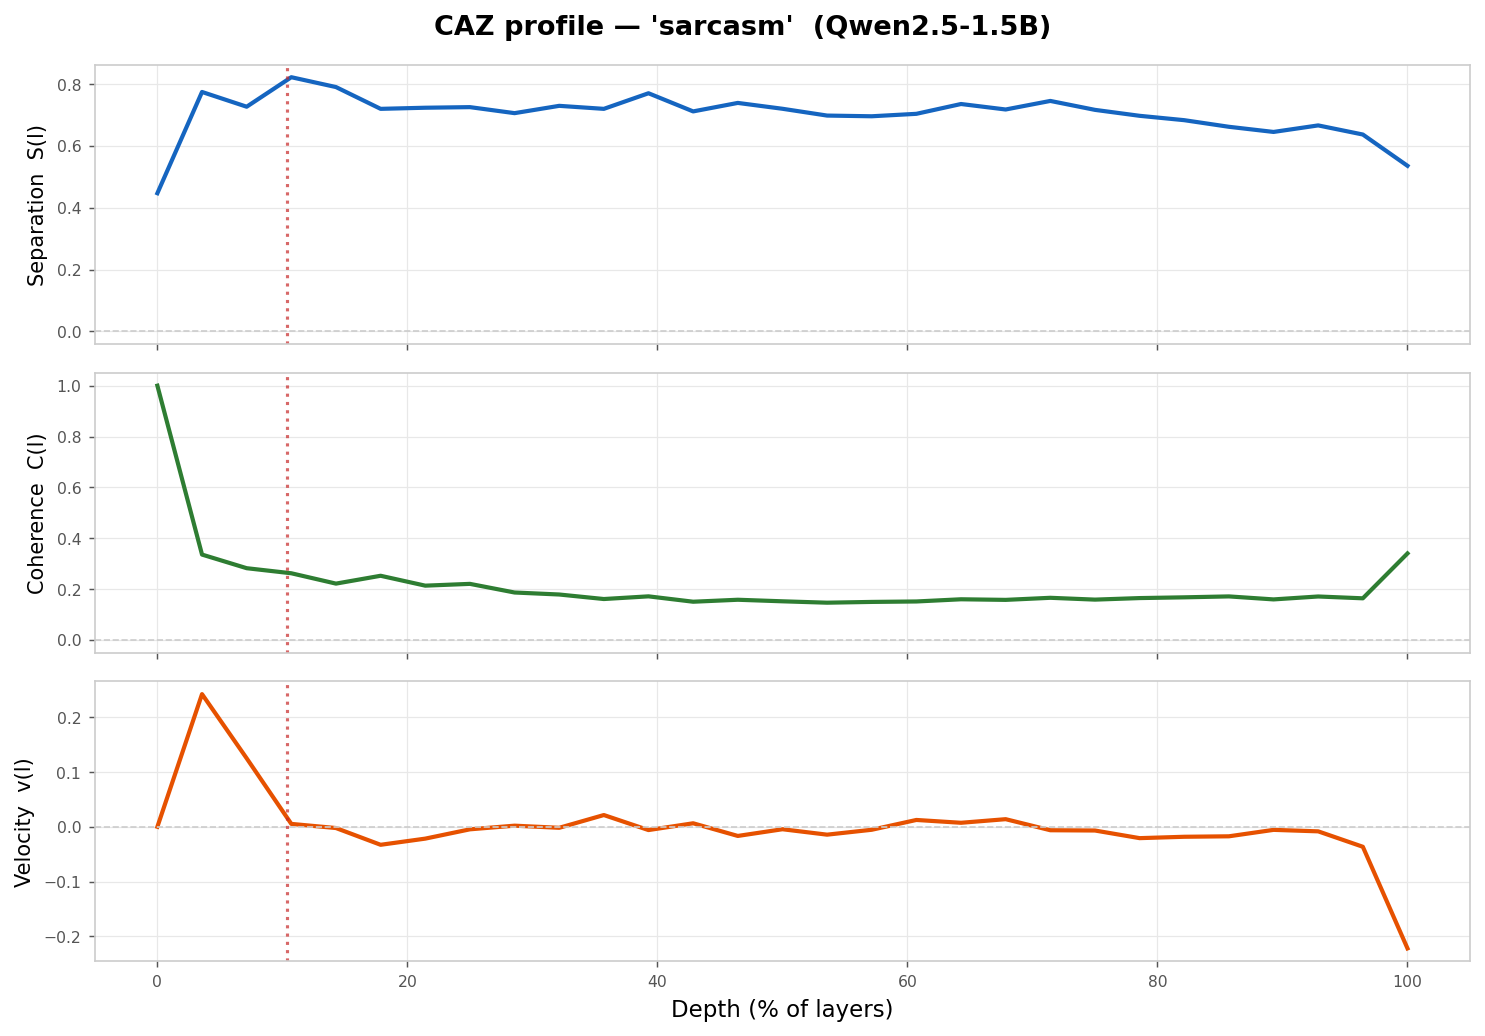

In [8]:
SIG_COLORS = {"separation": "#1565C0", "coherence": "#2E7D32", "velocity": "#E65100"}

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.patch.set_facecolor("white")
fig.suptitle(f"CAZ profile — '{CONCEPT_NAME}'  ({MODEL_ID.split('/')[-1]})",
             fontsize=13, fontweight="bold")

for ax, attr, ylabel, color in zip(
    axes,
    ["separation", "coherence", "velocity"],
    ["Separation  S(l)", "Coherence  C(l)", "Velocity  v(l)"],
    [SIG_COLORS["separation"], SIG_COLORS["coherence"], SIG_COLORS["velocity"]],
):
    vals = [getattr(m, attr) for m in metrics]
    ax.plot(depth_pct, vals, color=color, lw=2)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.axhline(0, color=THEME["spine"], lw=0.8, ls="--")
    apply_theme(ax)
    for region in profile.regions:
        ax.axvline(region.depth_pct, color="#C62828", lw=1.5, ls=":", alpha=0.7)

axes[-1].set_xlabel("Depth (% of layers)", fontsize=11)
plt.tight_layout()
plt.show()

## 6. How does your concept compare?

The chart below shows your concept's peak depth against the 17-concept paper reference. Where available, the reference comes from the same model you're running; otherwise it falls back to the Qwen2.5-7B paper baseline.

**A note on pair count and signal quality:** CAZ peak location can shift by 10–20 pp with fewer than ~10 pairs, especially for subtle pragmatic concepts (sarcasm, urgency, credibility). The presets use 10 pairs, which is reliable for most concepts. If your peak looks implausibly shallow or deep, try adding 5–10 more well-matched pairs before drawing conclusions.

Loaded baselines for Qwen2.5-1.5B (17 concepts)


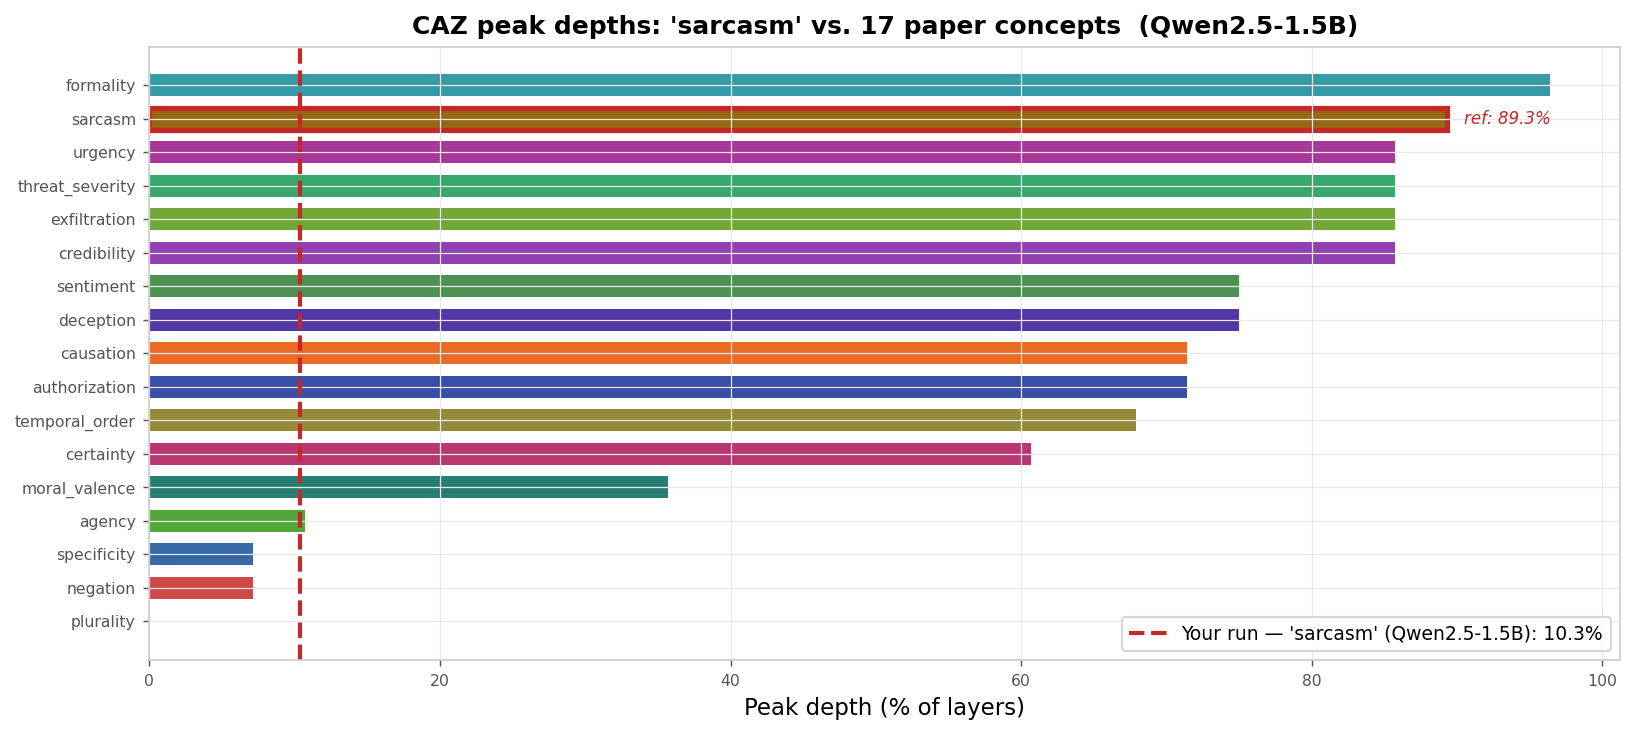

'sarcasm':
  Reference (Qwen2.5-1.5B): 89.3%
  Your run  (Qwen2.5-1.5B): 10.3%


In [9]:
PAPER_CONCEPTS = [
    "agency", "authorization", "causation", "certainty", "credibility",
    "deception", "exfiltration", "formality", "moral_valence", "negation",
    "plurality", "sarcasm", "sentiment", "specificity", "temporal_order",
    "threat_severity", "urgency",
]

# Model key uses the same convention as rosetta_tools.gem:
#   model_id.replace("/", "_").replace("-", "_")
HF_REPO = "james-ra-henry/Rosetta-Activations"
FALLBACK_KEY = "Qwen_Qwen2.5_7B"

def _model_key(mid):
    return mid.replace("/", "_").replace("-", "_")

# Try same-model baselines first, fall back to 7B
_mk = _model_key(MODEL_ID)
baseline = {}
_using_fallback = False
try:
    for c in PAPER_CONCEPTS:
        path = hf_hub_download(
            HF_REPO, filename=f"models/{_mk}/caz_{c}.json", repo_type="dataset",
        )
        with open(path) as f:
            baseline[c] = json.load(f)["layer_data"]["peak_depth_pct"]
    print(f"Loaded baselines for {MODEL_ID.split('/')[-1]} ({len(baseline)} concepts)")
except Exception:
    _using_fallback = True
    _mk = FALLBACK_KEY
    for c in PAPER_CONCEPTS:
        path = hf_hub_download(
            HF_REPO, filename=f"models/{_mk}/caz_{c}.json", repo_type="dataset",
        )
        with open(path) as f:
            baseline[c] = json.load(f)["layer_data"]["peak_depth_pct"]
    print(f"No same-model baseline found for {MODEL_ID.split('/')[-1]}; using Qwen2.5-7B reference.")
    print("  Tip: run with Qwen2.5-7B for an exact match.")

your_peak = profile.dominant.depth_pct
by_depth = sorted(baseline.items(), key=lambda x: x[1])
names_b = [c for c, _ in by_depth]
depths_b = [d for _, d in by_depth]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("white")

bar_colors = [concept_color(c) for c in names_b]
bars = ax.barh(names_b, depths_b, color=bar_colors, height=0.65, alpha=0.85)

# Highlight user's concept bar if it appears in the reference set
if CONCEPT_NAME in names_b:
    _idx = names_b.index(CONCEPT_NAME)
    bars[_idx].set_alpha(1.0)
    bars[_idx].set_edgecolor("#C62828")
    bars[_idx].set_linewidth(2.5)
    ax.text(
        depths_b[_idx] + 1.2, _idx,
        f"ref: {depths_b[_idx]:.1f}%",
        va="center", fontsize=8, color="#C62828", style="italic",
    )

# Always show your run as a vertical line
ax.axvline(
    your_peak, color="#C62828", lw=2, ls="--",
    label=f"Your run — '{CONCEPT_NAME}' ({MODEL_ID.split('/')[-1]}): {your_peak:.1f}%",
)
ax.legend(fontsize=9, loc="lower right")

ax.set_xlabel("Peak depth (% of layers)", fontsize=11)
_ref_label = MODEL_ID.split('/')[-1] if not _using_fallback else "Qwen2.5-7B reference"
ax.set_title(
    f"CAZ peak depths: '{CONCEPT_NAME}' vs. 17 paper concepts  ({_ref_label})",
    fontsize=12, fontweight="bold",
)
if _using_fallback:
    ax.set_xlabel(
        "Peak depth (% of layers)\n"
        "⚠  Reference bars are Qwen2.5-7B — absolute depths vary by model size",
        fontsize=10,
    )
apply_theme(ax)
plt.tight_layout()
plt.show()

if CONCEPT_NAME in baseline:
    ref_depth = baseline[CONCEPT_NAME]
    delta = abs(your_peak - ref_depth)
    print(f"'{CONCEPT_NAME}':")
    print(f"  Reference ({_ref_label}): {ref_depth:.1f}%")
    print(f"  Your run  ({MODEL_ID.split('/')[-1]}): {your_peak:.1f}%")
    if _using_fallback:
        print("  ⚠ Cross-model comparison — depth difference is expected.")
    elif delta > 15:
        print(f"  Note: {delta:.0f} pp gap. Subtle concepts (sarcasm, urgency) need 15+ pairs")
        print(f"  for a stable peak — try adding more matched pairs to narrow this.")
else:
    rank = sum(1 for d in depths_b if d < your_peak) + 1
    print(f"'{CONCEPT_NAME}' peaks at {your_peak:.1f}%  —  rank {rank} of {len(depths_b)+1} (shallow → deep)")
    if _using_fallback:
        print(f"  (Reference is Qwen2.5-7B; absolute depths differ on {MODEL_ID.split('/')[-1]}.)")


## 7. Batch concept sweep

Run a 10-pair probe across all 17 paper concepts to see the full CAZ landscape on this model. The chart includes a side-by-side comparison against the published Qwen2.5-7B results from the paper (Rosetta_Concept_Pairs dataset, 12–15 pairs/concept).

**Signal quality and pair count:** 4 pairs per concept gives a rough peak estimate; 10 pairs (used here) is stable for most concepts; 12–15 pairs (paper) gives publication-quality results. Pragmatic concepts like *sarcasm* and *urgency* are the most sensitive — the ordering tends to be preserved across pair counts, but the absolute depth can shift by up to ~15 pp.

In [10]:
# ── 17-concept sweep, 10 pairs each (170 total sentence pairs) ───────────────
MINI_CONCEPTS = {
    "agency": (
        ["She chose to resign despite heavy pressure from the board.",
         "He deliberately ignored the warning signs throughout the project.",
         "The team decided to delay the product launch after deliberation.",
         "She willingly accepted the full consequences of her actions.",
         "He resolved to pursue the case despite the significant personal cost.",
         "The committee voted to reject the amendment on principle.",
         "She intentionally withheld the information to protect her source.",
         "He chose to confront the situation rather than avoid it.",
         "They deliberately excluded the outliers from the final analysis.",
         "She opted to proceed without consulting legal counsel."],
        ["She resigned amid the pressure from the board.",
         "The warning signs were overlooked throughout the project.",
         "The product launch was delayed.",
         "She faced the full consequences of her actions.",
         "The case continued despite the significant personal cost.",
         "The amendment was rejected by the committee.",
         "The information was not included in the report.",
         "The situation was confronted.",
         "The outliers were excluded from the final analysis.",
         "The process proceeded without legal counsel present."],
    ),
    "authorization": (
        ["The board granted full approval for the acquisition.",
         "Her badge granted access to the secure floor.",
         "He was licensed to practice medicine in this state.",
         "The contract explicitly permitted subletting.",
         "The judge issued a warrant to search the premises.",
         "The regulator formally approved the clinical trial protocol.",
         "She was authorised to sign contracts on behalf of the company.",
         "The manager granted permission for the overtime hours.",
         "The document gave him power of attorney over the estate.",
         "The permit allowed construction to begin in the restricted zone."],
        ["The board discussed the acquisition.",
         "She used her badge at the entrance.",
         "He practiced medicine in the clinic.",
         "He sublet the apartment.",
         "The judge reviewed the case materials.",
         "The regulator examined the clinical trial protocol.",
         "She signed a document on behalf of the company.",
         "The manager noted the overtime hours.",
         "He managed the estate.",
         "Construction began in the zone."],
    ),
    "causation": (
        ["The pipe burst because the fitting had corroded.",
         "Heavy rain caused widespread flooding downstream.",
         "Chronic fatigue led to serious errors in the report.",
         "The new policy caused unemployment to rise sharply.",
         "The compound triggered an immune response in the subjects.",
         "Her sudden departure resulted in significant project delays.",
         "The malfunction was due to insufficient lubrication.",
         "Prolonged exposure to the chemical produced respiratory burns.",
         "The temperature drop caused the reservoir to freeze overnight.",
         "His intervention prevented further escalation of the conflict."],
        ["The pipe burst and the fitting was corroded.",
         "Heavy rain fell and there was widespread flooding downstream.",
         "There was chronic fatigue and serious errors appeared in the report.",
         "The new policy was introduced and unemployment rose sharply.",
         "The subjects were exposed to the compound and showed an immune response.",
         "She departed suddenly and the project experienced significant delays.",
         "The malfunction occurred and there was insufficient lubrication.",
         "There was prolonged chemical exposure and respiratory burns were observed.",
         "The temperature dropped and the reservoir froze overnight.",
         "He intervened and the conflict did not escalate further."],
    ),
    "certainty": (
        ["The results definitively prove the hypothesis.",
         "It is absolutely certain that costs will continue to rise.",
         "He knows for a fact the file was deleted.",
         "The outcome is guaranteed regardless of external conditions.",
         "The evidence conclusively establishes liability.",
         "She is completely sure the meeting was on Tuesday.",
         "There is no doubt that the findings are replicable.",
         "The diagnosis was confirmed beyond any reasonable doubt.",
         "This will inevitably fail without additional resources.",
         "The connection is undeniable and cannot be disputed."],
        ["The results are consistent with the hypothesis.",
         "Costs are likely to continue rising.",
         "He believes the file may have been deleted.",
         "The outcome is probable given current conditions.",
         "The evidence is compatible with liability.",
         "She thinks the meeting was probably on Tuesday.",
         "The findings are expected to be replicable.",
         "The diagnosis appears to be correct.",
         "This will likely fail without additional resources.",
         "The connection is plausible and difficult to dispute."],
    ),
    "credibility": (
        ["The study was peer-reviewed by three independent experts.",
         "She cited three corroborating primary sources for each claim.",
         "His testimony was confirmed by two independent witnesses.",
         "The sensor reading was verified against a calibrated reference.",
         "The claim was substantiated by multiple government records.",
         "Three separate audits independently reached the same conclusion.",
         "The finding has been replicated in six independent laboratories.",
         "She produced documentary evidence supporting every assertion.",
         "The analysis was validated on a separate holdout dataset.",
         "The report was cross-checked against official court transcripts."],
        ["The study was conducted by the internal team.",
         "She cited one source for each claim.",
         "He gave a testimony at the hearing.",
         "The sensor produced a reading.",
         "The claim appeared in an internal memo.",
         "One audit was conducted and a conclusion was reached.",
         "The finding appeared in one published paper.",
         "She made several assertions in the report.",
         "The analysis used the full available dataset.",
         "The report referenced internal documentation."],
    ),
    "deception": (
        ["He deliberately omitted the key evidence from the report.",
         "She posed as a doctor to gain access to the ward.",
         "The company concealed the safety violations from regulators.",
         "He fabricated the test results to meet the deadline.",
         "She misrepresented her qualifications to secure the position.",
         "He forged the signature on the approval documents.",
         "The firm disguised the payments as legitimate consulting fees.",
         "She lied about her whereabouts on the night in question.",
         "He planted false evidence to mislead the investigators.",
         "The spokesperson gave a deliberately misleading account of events."],
        ["He did not include the key evidence in the report.",
         "She was a doctor with access to the ward.",
         "The company disclosed the safety findings to regulators.",
         "He submitted the test results by the deadline.",
         "She listed her qualifications when applying for the position.",
         "He signed the approval documents.",
         "The firm recorded the payments as consulting fees.",
         "She described her whereabouts on the night in question.",
         "He provided the investigators with the available evidence.",
         "The spokesperson gave an account of the events."],
    ),
    "exfiltration": (
        ["He copied the files to a USB drive before leaving the company.",
         "She emailed the proprietary source code to a competitor.",
         "The agent smuggled the classified documents across the border.",
         "He downloaded the entire customer database to his personal laptop.",
         "She transferred the encryption keys to an external server.",
         "He printed the confidential schematics and took them home.",
         "The employee extracted salary data and shared it externally.",
         "She forwarded the internal audit findings to a journalist.",
         "He secretly recorded the executive briefing and distributed it.",
         "The contractor uploaded production code to a personal repository."],
        ["He had read-only access to company files.",
         "She communicated with external partners about the project.",
         "The agent crossed the border with official documentation.",
         "He accessed the customer database on his work laptop.",
         "She managed the encryption keys on the corporate server.",
         "He reviewed the confidential schematics in the secure office.",
         "The employee had access to salary data in the HR system.",
         "She was aware of the internal audit findings.",
         "He attended the executive briefing.",
         "The contractor worked with the production codebase on-site."],
    ),
    "formality": (
        ["I would be grateful if you could respond at your earliest convenience.",
         "Please find enclosed the documentation you requested.",
         "The committee has resolved to adopt the proposal unanimously.",
         "We respectfully decline the offer as presented.",
         "I wish to draw your attention to the following discrepancy.",
         "The board hereby ratifies the amendment to the articles.",
         "Further to our previous correspondence, I write to confirm the arrangement.",
         "The undersigned acknowledges receipt of the foregoing notice.",
         "We are pleased to extend an invitation to attend the annual symposium.",
         "Your application has been received and is currently under consideration."],
        ["Hey, reply whenever you get a chance.",
         "Here's the stuff you asked for.",
         "We're all voting yes — going with the plan.",
         "No thanks, not interested.",
         "Just wanted to flag something that looks off.",
         "The board said yes to the change.",
         "Following up on what we talked about last time.",
         "Got the notice, thanks.",
         "You're invited to come to the event.",
         "We got your application and we're looking at it now."],
    ),
    "moral_valence": (
        ["It was wrong to lie to protect himself at others' expense.",
         "Donating anonymously was a genuinely kind and generous act.",
         "Abandoning the injured child was unforgivable.",
         "She acted courageously to protect others at great personal risk.",
         "Exploiting the elderly investor was deeply unconscionable.",
         "His selfless sacrifice during the crisis deserves the highest admiration.",
         "Falsifying the safety data was a grave and inexcusable moral failure.",
         "She showed remarkable integrity by refusing the substantial bribe.",
         "Torturing the prisoner was a profound violation of human dignity.",
         "The whistleblower did the right thing at considerable personal cost."],
        ["He lied to protect himself when others were present.",
         "He donated anonymously to the charity.",
         "The injured child was left at the scene.",
         "She acted to protect others and sustained an injury in doing so.",
         "The elderly investor lost money in the scheme.",
         "He died during the operation.",
         "The safety data was altered before the submission.",
         "She declined the payment that was offered to her.",
         "The prisoner was held in the detention facility.",
         "The employee reported the incident to the relevant regulators."],
    ),
    "negation": (
        ["The report was not submitted on time.",
         "She did not agree with the proposed decision.",
         "No funds were allocated to the infrastructure project.",
         "The experiment failed to replicate the original findings.",
         "He refused to sign the contract under those conditions.",
         "The safety checks were never completed before the launch.",
         "Nothing in the evidence pointed toward that conclusion.",
         "The team was unable to reproduce the result in testing.",
         "She denied having any prior knowledge of the incident.",
         "The medication showed no statistically significant effect."],
        ["The report was submitted before the deadline.",
         "She agreed with the proposed decision.",
         "Funds were allocated to the infrastructure project.",
         "The experiment successfully replicated the original findings.",
         "He signed the contract under the agreed conditions.",
         "The safety checks were completed before the launch.",
         "Several elements of the evidence pointed toward that conclusion.",
         "The team reproduced the result successfully in testing.",
         "She acknowledged having prior knowledge of the incident.",
         "The medication showed a statistically significant effect."],
    ),
    "plurality": (
        ["The engineers reviewed the designs and flagged the issues.",
         "Multiple errors were found across the report.",
         "The students submitted their assignments on time.",
         "Several birds perched on the fence simultaneously.",
         "The investigators collected statements from all witnesses.",
         "Three servers failed during the overnight outage.",
         "The researchers published their findings in a joint paper.",
         "Dozens of patients independently reported the same side effect.",
         "The consultants presented their recommendations to the board.",
         "Five separate auditors reached the same conclusion independently."],
        ["The engineer reviewed the design and flagged the issue.",
         "An error was found in the report.",
         "The student submitted the assignment on time.",
         "A bird perched on the fence.",
         "The investigator collected a statement from the witness.",
         "One server failed during the overnight outage.",
         "The researcher published the finding in a paper.",
         "A patient reported the side effect.",
         "The consultant presented a recommendation to the board.",
         "One auditor reached the conclusion."],
    ),
    "sarcasm": (
        ["Oh sure, because that plan always works out perfectly.",
         "Right, because we all love three-hour meetings at 7 a.m.",
         "Great — what could possibly go wrong with that idea?",
         "Yeah, I'm sure skipping the tests will be totally fine in production.",
         "Oh wonderful, the system crashed again — truly unexpected.",
         "Of course it rained the one day I forgot my umbrella.",
         "Brilliant plan, deleting the only backup — very smart move.",
         "Sure, adding more features always makes software faster.",
         "Absolutely, a spreadsheet is obviously the right tool for this.",
         "Yeah, let's just ignore all the warning lights — I'm sure it's nothing."],
        ["That plan has worked well in several past situations.",
         "Morning meetings are standard practice on the team.",
         "The idea looks solid and the risks appear manageable.",
         "Skipping the tests shortened the release cycle this time.",
         "The system crashed due to an unexpected memory overflow.",
         "It rained unexpectedly; the forecast had shown a 40% chance.",
         "Deleting the old backup freed up significant disk space.",
         "Adding features typically increases the scope of the project.",
         "A spreadsheet is a practical tool for this data size.",
         "The warning lights have been active for several weeks."],
    ),
    "sentiment": (
        ["The concert was absolutely wonderful — one of the best nights of my life.",
         "I deeply regret every choice that led me to this miserable situation.",
         "What a joyful, uplifting experience — I left genuinely moved.",
         "The loss was devastating and I still haven't recovered emotionally.",
         "Her performance was breathtaking, a true artistic triumph.",
         "The food was terrible and the service made everything considerably worse.",
         "I am so grateful for everything this team has accomplished together.",
         "The holiday was a complete disaster from start to finish.",
         "Reading that letter filled me with warmth and genuine hope.",
         "The product is deeply disappointing and I feel thoroughly let down."],
        ["The concert took place last night at the city auditorium.",
         "I made several choices that year that shaped my circumstances.",
         "The experience lasted about two hours and I then left.",
         "There was a loss and I did not return to the activity.",
         "Her performance lasted forty minutes on the main stage.",
         "The food was prepared and the service continued through the evening.",
         "The team completed the project and submitted the final report.",
         "The holiday spanned ten days across three countries.",
         "I received a letter containing information about the arrangement.",
         "The product arrived in standard packaging on Thursday morning."],
    ),
    "specificity": (
        ["The drug reduced mortality by 34% in patients over 65.",
         "The bolt requires exactly 12.5 Nm of torque to secure properly.",
         "She arrived at 7:43 AM on March 14th.",
         "The budget was cut by precisely $2.3 million.",
         "The temperature must be maintained at 37.2 °C ± 0.1 °C.",
         "Exactly 847 participants completed the follow-up survey.",
         "The compound has a plasma half-life of 4.7 hours.",
         "The pipeline carries 1.2 million barrels per day at peak throughput.",
         "Response times improved by 23 milliseconds after the patch.",
         "The document was filed on 9 April 2023 at 14:17 local time."],
        ["The drug reduced mortality somewhat in older patients.",
         "The bolt requires moderate torque to secure properly.",
         "She arrived in the morning in mid-March.",
         "The budget was reduced by a significant amount.",
         "The temperature must be maintained within a narrow range.",
         "Most participants completed the follow-up survey.",
         "The compound has a short plasma half-life.",
         "The pipeline carries a large volume at peak throughput.",
         "Response times improved noticeably after the patch.",
         "The document was filed earlier this year."],
    ),
    "temporal_order": (
        ["She graduated before she received the job offer.",
         "The alarm sounded prior to the evacuation beginning.",
         "He signed the contract after reading it carefully.",
         "The bridge was completed following the final safety inspection.",
         "She had left the building before the fire started.",
         "The suspect was identified subsequent to the initial arrest.",
         "The policy was revised in advance of the annual board review.",
         "He retired after serving thirty years with the organisation.",
         "The vaccine received approval before the second wave arrived.",
         "She filed the formal complaint prior to the internal investigation."],
        ["She graduated and later received a job offer.",
         "The alarm sounded and an evacuation took place.",
         "He signed the contract and then read through it.",
         "The bridge was completed and the safety inspection followed.",
         "She had left the building and the fire started.",
         "The suspect was identified and was subsequently arrested.",
         "The policy was revised and the annual board review took place.",
         "He retired having served thirty years with the organisation.",
         "The vaccine received approval and the second wave arrived.",
         "She filed the formal complaint and an internal investigation began."],
    ),
    "threat_severity": (
        ["He threatened to release the compromising data unless paid immediately.",
         "The armed intruder demanded everyone get down on the floor.",
         "She warned she would expose the fraud publicly if her demands were ignored.",
         "The message contained a credible and specific threat to the facility.",
         "He issued an ultimatum: comply fully or face legal action by Friday.",
         "The email threatened to permanently destroy the company's reputation.",
         "She told him his entire career would be over if he chose to testify.",
         "The group threatened to detonate a device inside the building.",
         "He demanded the ransom payment or the hostage would be harmed.",
         "The letter warned of severe consequences if the outstanding debt went unpaid."],
        ["He mentioned the data during the course of the negotiation.",
         "The intruder entered the building through a side door.",
         "She mentioned the discrepancy to a colleague informally.",
         "The message raised general security concerns.",
         "He set a Friday deadline for a response to the business proposal.",
         "The email discussed potential reputational risks in general terms.",
         "She told him his role might change if he chose to testify.",
         "The group issued a public statement about building security procedures.",
         "He requested payment within seven business days.",
         "The letter noted that the outstanding debt remained unpaid."],
    ),
    "urgency": (
        ["You must evacuate the building immediately — there is no time to waste.",
         "Call 911 right now, this is a life-threatening emergency.",
         "The deadline is in ten minutes — you must submit the form now.",
         "Act immediately before it is too late and the opportunity is gone.",
         "The patient requires surgery within the hour or the risk becomes critical.",
         "Stop everything you are doing and read this message right now.",
         "You have exactly five minutes to respond before the offer window closes.",
         "The system is critically failing — you must intervene now.",
         "Evacuate the entire floor now — do not wait for further instructions.",
         "This requires your immediate attention and absolutely cannot be deferred."],
        ["You should consider leaving the area when you get a chance.",
         "Contact emergency services when it is convenient.",
         "The deadline is next week — please plan your submission accordingly.",
         "Consider taking action at a time that suits your schedule.",
         "The patient is scheduled for surgery in the coming weeks.",
         "Please review this document when you have a moment.",
         "You are welcome to respond within the next few business days.",
         "The system is currently experiencing reduced performance.",
         "Please vacate the floor at the end of the working day.",
         "This item can be addressed at your next available opportunity."],
    ),
}

n_concepts = len(MINI_CONCEPTS)
n_pairs_each = len(next(iter(MINI_CONCEPTS.values()))[0])
print(f"Running {n_concepts}-concept sweep on {MODEL_ID.split('/')[-1]}...")
print(f"  {n_pairs_each} pairs/concept  ×  {n_concepts} concepts  =  {n_concepts * n_pairs_each} total sentence pairs\n")

sweep_results = {}
for i, (cname, (pos, neg)) in enumerate(MINI_CONCEPTS.items()):
    acts = extract_contrastive_activations(
        model, tokenizer, pos, neg, device=device, batch_size=4,
    )
    m = compute_layer_metrics(acts)
    p = find_caz_regions(m)
    sweep_results[cname] = p
    peak = p.dominant.depth_pct
    mm   = "multimodal" if p.is_multimodal else "unimodal  "
    sep  = p.dominant.peak_separation
    print(f"  [{i+1:2d}/{n_concepts}] {cname:<20s}  peak {peak:5.1f}%  {mm}  S={sep:.3f}")

print(f"\nDone. {len(sweep_results)} concepts processed.")


Running 17-concept sweep on Qwen2.5-1.5B...
(68 total sentence pairs)

  [ 1/17] agency               peak  93.1%  multimodal  S=0.875
  [ 2/17] authorization        peak  10.3%  unimodal    S=1.000
  [ 3/17] causation            peak   3.4%  unimodal    S=0.768
  [ 4/17] certainty            peak  37.9%  unimodal    S=0.600
  [ 5/17] credibility          peak   6.9%  unimodal    S=1.012
  [ 6/17] deception            peak  51.7%  unimodal    S=0.770
  [ 7/17] exfiltration         peak  55.2%  unimodal    S=0.928
  [ 8/17] formality            peak  10.3%  multimodal  S=1.070
  [ 9/17] moral_valence        peak  17.2%  unimodal    S=1.057
  [10/17] negation             peak  37.9%  multimodal  S=0.664
  [11/17] plurality            peak   6.9%  multimodal  S=0.607
  [12/17] sarcasm              peak  44.8%  unimodal    S=0.988
  [13/17] sentiment            peak  27.6%  unimodal    S=1.012
  [14/17] specificity          peak   3.4%  unimodal    S=1.320
  [15/17] temporal_order       pe

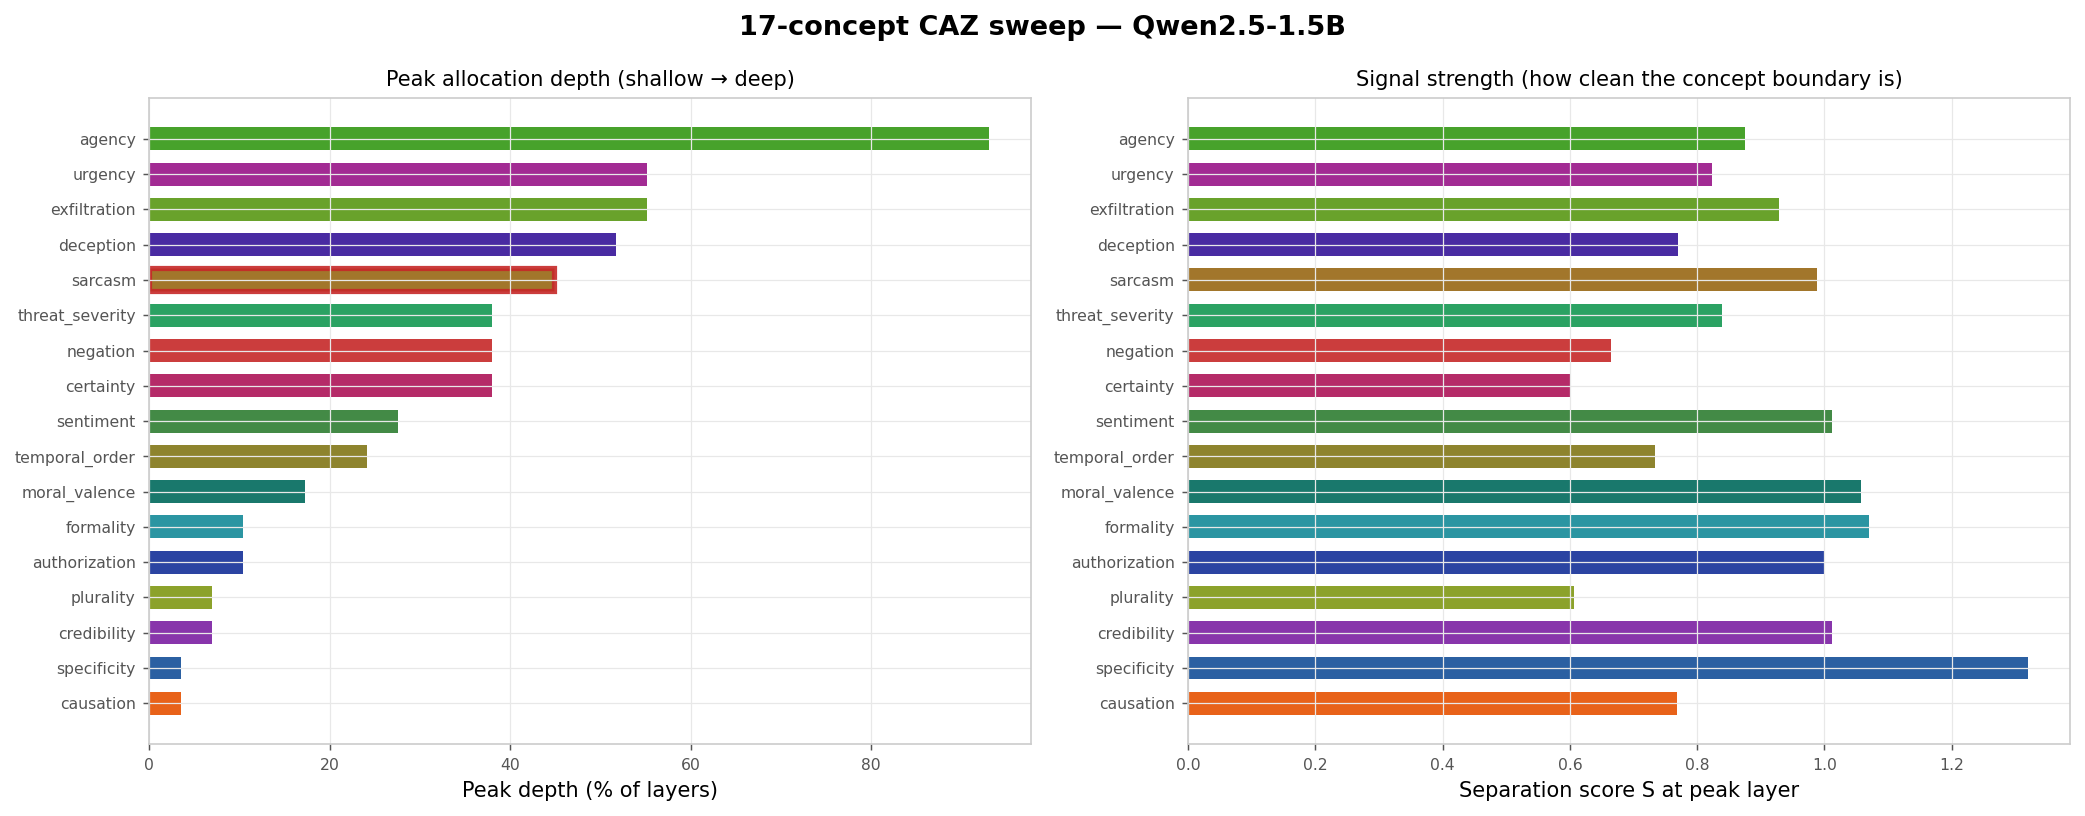


Summary across 17 concepts:
  Multimodal (two assembly events): 5/17
  Shallow zone (< 30%): 9
  Mid zone (30–60%):    7
  Deep zone (≥ 60%):    1

  'sarcasm' (sarcasm): 44.8% depth, S=0.988


In [11]:
# ── Download Qwen2.5-7B paper baselines for comparison ───────────────────────
_PAPER_KEY = "Qwen_Qwen2.5_7B"
_paper_depths = {}
for _c in sweep_results:
    try:
        _path = hf_hub_download(
            "james-ra-henry/Rosetta-Activations",
            filename=f"models/{_PAPER_KEY}/caz_{_c}.json",
            repo_type="dataset",
        )
        with open(_path) as _f:
            _paper_depths[_c] = json.load(_f)["layer_data"]["peak_depth_pct"]
    except Exception:
        pass
_has_paper = len(_paper_depths) > 0
print(f"Paper baselines loaded: {len(_paper_depths)}/{len(sweep_results)} concepts")

# ── Sort by this model's depths ───────────────────────────────────────────────
sweep_depths = {c: p.dominant.depth_pct for c, p in sweep_results.items()}
by_d = sorted(sweep_depths.items(), key=lambda x: x[1])
s_names  = [c for c, _ in by_d]
s_depths = [d for _, d in by_d]

n_panels = 3 if _has_paper else 2
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))
fig.patch.set_facecolor("white")
_n_pairs = len(next(iter(MINI_CONCEPTS.values()))[0])
fig.suptitle(
    f"17-concept CAZ sweep — {MODEL_ID.split('/')[-1]}",
    fontsize=13, fontweight="bold",
)

# Panel 1: peak depths (this model)
ax = axes[0]
s_colors = [concept_color(c) for c in s_names]
_bars = ax.barh(s_names, s_depths, color=s_colors, height=0.65, alpha=0.9)
if CONCEPT_NAME in s_names:
    _si = s_names.index(CONCEPT_NAME)
    _bars[_si].set_edgecolor("#C62828")
    _bars[_si].set_linewidth(2.5)
ax.set_xlabel("Peak depth (% of layers)", fontsize=10)
ax.set_title(
    f"This model: {MODEL_ID.split('/')[-1]}\n({_n_pairs} pairs/concept)",
    fontsize=10,
)
apply_theme(ax)

# Panel 2: separation score
ax2 = axes[1]
sep_vals = [sweep_results[c].dominant.peak_separation for c in s_names]
ax2.barh(s_names, sep_vals, color=s_colors, height=0.65, alpha=0.9)
ax2.set_xlabel("Separation score S at peak", fontsize=10)
ax2.set_title("Signal strength\n(how clean the concept boundary is)", fontsize=10)
apply_theme(ax2)

# Panel 3: paper comparison (same concept order as panel 1)
if _has_paper:
    ax3 = axes[2]
    paper_ordered = [_paper_depths.get(c, float("nan")) for c in s_names]
    _pmissing = [i for i, v in enumerate(paper_ordered) if v != v]  # nan check
    _pvals    = [v if v == v else 0 for v in paper_ordered]
    p_colors  = [concept_color(c) for c in s_names]
    _pbars = ax3.barh(s_names, _pvals, color=p_colors, height=0.65, alpha=0.9)
    for mi in _pmissing:
        _pbars[mi].set_alpha(0.15)
    ax3.set_xlabel("Peak depth (% of layers)", fontsize=10)
    ax3.set_title(
        f"Paper: Qwen2.5-7B\n(Rosetta_Concept_Pairs, 12–15 pairs/concept)",
        fontsize=10,
    )
    ax3.set_yticklabels([])  # concepts readable from panel 1
    apply_theme(ax3)

plt.tight_layout()
plt.show()

# ── Text summary ──────────────────────────────────────────────────────────────
n_multi = sum(1 for p in sweep_results.values() if p.is_multimodal)
print(f"\nSummary — {MODEL_ID.split('/')[-1]} ({_n_pairs} pairs/concept):")
print(f"  Multimodal (two assembly events): {n_multi}/{len(sweep_results)}")
print(f"  Shallow zone (< 30%):  {sum(1 for d in s_depths if d < 30)}")
print(f"  Mid zone   (30–60%):   {sum(1 for d in s_depths if 30 <= d < 60)}")
print(f"  Deep zone  (≥ 60%):    {sum(1 for d in s_depths if d >= 60)}")
if CONCEPT_NAME in sweep_depths:
    print(f"\n  '{CONCEPT_NAME}': {sweep_depths[CONCEPT_NAME]:.1f}% depth, "
          f"S={sweep_results[CONCEPT_NAME].dominant.peak_separation:.3f}")
if _has_paper and CONCEPT_NAME in _paper_depths:
    _delta = abs(sweep_depths[CONCEPT_NAME] - _paper_depths[CONCEPT_NAME])
    print(f"  Paper (7B): {_paper_depths[CONCEPT_NAME]:.1f}% depth  "
          f"(Δ {_delta:.1f} pp from this model)")


## Next steps

- Try different concepts — does *uncertainty* behave differently from *certainty*? Does *irony* look like *sarcasm*?
- Swap `MODEL_ID` for any HuggingFace model: `extract_contrastive_activations` works with any model that exposes `output_hidden_states=True`
- **`03_caz_implementation_demo.ipynb`** — implement the metrics and Procrustes alignment from scratch, and reproduce the cross-architecture convergence result from Paper 4

| Paper | |
|-------|-|
| Paper 1 — CAZ Framework | [Henry 2026a](https://arxiv.org/abs/PLACEHOLDER) |
| Paper 4 — Cross-architecture PRH | [Henry 2026d](https://arxiv.org/abs/PLACEHOLDER) |
| `rosetta_tools` | [GitHub](https://github.com/jamesrahenry/Rosetta_Tools) |